# 1. Business Understanding
## 1.1 Business Overview
The superbike industry is characterized by intense competition between Japanese and European manufacturers. While brands like Kawasaki have built a reputation on raw performance and "Ninja" branding, consumers and stakeholders lack an objective, data-driven way to compare engine tuning and efficiency across different brands and engine displacements. This project evaluates how these engineering philosophies translate into real-world performance metrics.

## 1.2 Problem Statement
Motorcycle technical specifications are often presented in inconsistent formats (mixing HP and PS units, or including RPM data in string format), making direct comparison difficult. Furthermore, traditional metrics like "Total Horsepower" favor larger engines, masking the true engineering efficiency of a brand. Without a normalized metric like Horsepower per CC (Efficiency), it is impossible to determine which brand truly maximizes its engine technology.

## 1.3 Business Objectives
Main Objective: To perform a comparative performance analysis of major superbike brands (Kawasaki, BMW, Honda, Suzuki, Yamaha) to identify the "Efficiency King" across various engine classes.

### 1.3.1 Specific Objectives:

- Clean and normalize technical specifications from a raw motorcycle dataset using Regex and type conversion.

- Identify and isolate data anomalies and physical impossibilities (outliers) that skew market analysis.

- Quantify the correlation between engine size (CC) and performance efficiency.

- Determine which brand provides the highest "tuning density" (HP/CC) in the Entry-level and Superbike categories.

### 1.3.2 Research Questions
- Does Kawasaki maintain a higher efficiency rating in entry-level bikes (under 400cc) compared to its rivals?

- Is there a point of diminishing returns where increasing engine displacement (CC) leads to a decrease in overall engine efficiency?

- How closely matched are the top-tier "Liter Bikes" (1000cc) across different manufacturers in the 2026 market?

# 2. Data Understanding
## 2.1 Data Source and Scope
The dataset used is bikes_data.csv, containing recent technical specs (2022–2026) for five major companies: BMW, Honda, Kawasaki, Suzuki, and Yamaha. It includes fields for Model, Year, Horsepower, and Number of CC.

In [2]:
import pandas as pd
import io
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings

warnings.filterwarnings('ignore')

# Global plot aesthetics
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

BRAND_COLORS = {
    'Kawasaki': '#3ECF4A',   # Kawasaki Green
    'BMW':      '#1C69D4',   # BMW Blue
    'Honda':    '#E40012',   # Honda Red
    'Suzuki':   '#FF6B00',   # Suzuki Orange
    'Yamaha':   '#0F1E7A',   # Yamaha Deep Blue
}

print('✅ Libraries loaded successfully.')
print(f'   pandas  {pd.__version__}  |  numpy  {np.__version__}  |  seaborn  {sns.__version__}')

# Stable link to a curated bike insights CSV
url = "https://raw.githubusercontent.com/Saniyaaahh/Bike_Insights_Hub/main/bikes_data.csv"

# Getting the data
response = requests.get(url)
df = pd.read_csv(io.StringIO(response.text))


✅ Libraries loaded successfully.
   pandas  2.2.2  |  numpy  1.26.4  |  seaborn  0.13.2


In [3]:
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum())
print('\n--- Sample raw Horsepower values ---')
print(df['Horsepower'].head(8).tolist())

--- Data Types ---
Company                object
Country of Origin      object
Model                  object
Number of cc           object
Horsepower             object
Torque                 object
Transmission Type      object
Drivetrain             object
Number of Seating       int64
Price (in INR)         object
Year                    int64
Looks                  object
Body Type              object
Engine Type            object
Number of Cylinders    object
dtype: object

--- Missing Values ---
Company                0
Country of Origin      0
Model                  0
Number of cc           0
Horsepower             0
Torque                 0
Transmission Type      0
Drivetrain             0
Number of Seating      0
Price (in INR)         0
Year                   0
Looks                  0
Body Type              0
Engine Type            0
Number of Cylinders    1
dtype: int64

--- Sample raw Horsepower values ---
['100 hp', '100 hp', '15 hp', '95 hp', '175 hp', '11 hp', '27 hp', 

### 2.1 Raw Data Observations

Key quality issues identified:

| Field | Issue | Example Raw Value |
|-------|-------|------------------|
| `Horsepower` | Stored as string with unit mix (HP / PS) and RPM suffix | `'39 PS @ 11000 rpm'` |
| `CC` | Generally numeric but may contain outliers | `'999'` |
| `Brand` | Needs value-count audit | — |

> **Decision:** Extract only the leading numeric value from `Horsepower` using Regex, then convert PS → HP where flagged.

---
## 3. Data Cleaning Pipeline

In [4]:
# ── Step 1: Extract numeric HP/PS value ──────────────────────────────────────
def extract_hp(raw: str) -> float:
    """
    Extract the leading numeric value from a raw horsepower string.
    Handles formats like:
      '39 PS @ 11000 rpm'  →  39.0
      '189.9 HP'           →  189.9
      '200'                →  200.0
    """
    if pd.isna(raw):
        return np.nan
    match = re.search(r'([\d]+\.?[\d]*)', str(raw))
    return float(match.group(1)) if match else np.nan

# ── Step 2: Detect PS unit and convert (1 PS ≈ 0.9863 HP) ───────────────────
def is_ps(raw: str) -> bool:
    return bool(re.search(r'\bPS\b', str(raw), re.IGNORECASE))

PS_TO_HP = 0.9863

df['_is_ps']     = df['Horsepower'].apply(is_ps)
df['HP_raw']     = df['Horsepower'].apply(extract_hp)
df['HP_cleaned'] = df.apply(
    lambda r: round(r['HP_raw'] * PS_TO_HP, 2) if r['_is_ps'] else r['HP_raw'],
    axis=1
)

ps_count = df['_is_ps'].sum()
print(f'  PS unit detected in {ps_count} rows → converted to HP (×{PS_TO_HP})')
print(f'  HP_cleaned null count: {df["HP_cleaned"].isnull().sum()}')

# Preview the transformation
df[['Model', 'Horsepower', '_is_ps', 'HP_raw', 'HP_cleaned']].head(8)

  PS unit detected in 50 rows → converted to HP (×0.9863)
  HP_cleaned null count: 0


,Model,Horsepower,_is_ps,HP_raw,HP_cleaned
0,RS 660,100 hp,False,100.0,100.0
1,Tuono 660,100 hp,False,100.0,100.0
2,RS 125,15 hp,False,15.0,15.0
3,Shiver 900,95 hp,False,95.0,95.0
4,Tuono 1100,175 hp,False,175.0,175.0
5,TNT 125,11 hp,False,11.0,11.0
6,TNT 250,27 hp,False,27.0,27.0
7,TNT 300,39 hp,False,39.0,39.0


In [5]:
print(df.columns.tolist())
print(df.head(2))

['Company', 'Country of Origin', 'Model', 'Number of cc', 'Horsepower', 'Torque', 'Transmission Type', 'Drivetrain', 'Number of Seating', 'Price (in INR)', 'Year', 'Looks', 'Body Type', 'Engine Type', 'Number of Cylinders', '_is_ps', 'HP_raw', 'HP_cleaned']
   Company Country of Origin      Model Number of cc Horsepower Torque  \
0  Aprilia             Italy     RS 660          659     100 hp  67 Nm   
1  Aprilia             Italy  Tuono 660          659     100 hp  67 Nm   

      Transmission Type Drivetrain  Number of Seating Price (in INR)  Year  \
0  6-speed quickshifter      Chain                  2  INR 10,99,000  2021   
1  6-speed quickshifter      Chain                  2  INR 11,99,000  2021   

   Looks Body Type    Engine Type Number of Cylinders  _is_ps  HP_raw  \
0  Sport     Naked  Parallel-twin                   2   False   100.0   
1  Sport     Naked  Parallel-twin                   2   False   100.0   

   HP_cleaned  
0       100.0  
1       100.0  


In [6]:
df['CC'] = pd.to_numeric(df['Number of cc'], errors='coerce')

print('CC descriptive stats:')
print(df['CC'].describe().round(1))

# Flag physically impossible values (motorcycles: 50cc – 2500cc range)
out_of_range = df[(df['CC'] < 50) | (df['CC'] > 2500)]
print(f'\nRows with CC outside [50, 2500]: {len(out_of_range)}')
if not out_of_range.empty:
    print(out_of_range[['Company', 'Model', 'Year', 'CC']])

CC descriptive stats:
count     312.0
mean      436.1
std       416.7
min         7.2
25%       125.0
50%       264.1
75%       649.0
max      2458.0
Name: CC, dtype: float64

Rows with CC outside [50, 2500]: 7
              Company                       Model  Year    CC
228           Ontrack  Brutus Single Speed MTB 29  2023  29.0
274  Zero Motorcycles                      Zero S  2023   7.2
275  Zero Motorcycles                     Zero SR  2023  11.4
276  Zero Motorcycles                   Zero SR/F  2023  14.4
277  Zero Motorcycles                     Zero DS  2023  11.4
278  Zero Motorcycles                     Zero FX  2023   7.2
290  Genuine Scooters                    Buddy 50  2023  49.0


In [7]:
df['Efficiency'] = (df['HP_cleaned'] / df['CC']).round(4)

print('Efficiency (HP/CC) descriptive stats:')
print(df['Efficiency'].describe().round(4))

# Flag outlier efficiencies (real-world range: 0.05 – 0.25)
outliers = df[df['Efficiency'] > 0.25]
print(f'\n⚠️  Outlier records (Efficiency > 0.25): {len(outliers)}')
print(outliers[['Company', 'Model', 'Year', 'CC', 'HP_cleaned', 'Efficiency']])

Efficiency (HP/CC) descriptive stats:
count    312.0000
mean       0.2547
std        1.1176
min        0.0100
25%        0.0798
50%        0.0910
75%        0.1128
max       10.2778
Name: Efficiency, dtype: float64

⚠️  Outlier records (Efficiency > 0.25): 12
                   Company                       Model  Year     CC  \
221  Triton Electric Bikes                     Artemis  2023  750.0   
222                 Apollo                     Artemis  2022  250.0   
223          Hero Electric                     Artemis  2021  250.0   
224                 Ampere                     Artemis  2020  250.0   
228                Ontrack  Brutus Single Speed MTB 29  2023   29.0   
240                Victory               Cross Country  2017  106.0   
241                Victory                       Judge  2017  106.0   
274       Zero Motorcycles                      Zero S  2023    7.2   
275       Zero Motorcycles                     Zero SR  2023   11.4   
276       Zero Motorcycles    

In [8]:
df_clean = df[
    (df['Efficiency'].between(0.05, 0.25)) &
    (df['HP_cleaned'].notna()) &
    (df['CC'].notna())
].copy()

# Drop helper columns
df_clean.drop(columns=['_is_ps', 'HP_raw'], inplace=True)

print(f'Rows before cleaning : {len(df)}')
print(f'Rows after cleaning  : {len(df_clean)}')
print(f'Removed              : {len(df) - len(df_clean)} rows (outliers / nulls)')

df_clean[['Company', 'Model', 'Year', 'CC', 'HP_cleaned', 'Efficiency']].head(10)

Rows before cleaning : 362
Rows after cleaning  : 286
Removed              : 76 rows (outliers / nulls)


,Company,Model,Year,CC,HP_cleaned,Efficiency
0,Aprilia,RS 660,2021,659.0,100.0,0.1517
1,Aprilia,Tuono 660,2021,659.0,100.0,0.1517
2,Aprilia,RS 125,2022,124.9,15.0,0.1201
3,Aprilia,Shiver 900,2022,896.0,95.0,0.1060
4,Aprilia,Tuono 1100,2022,1077.0,175.0,0.1625
5,Benelli,TNT 125,2023,125.0,11.0,0.0880
6,Benelli,TNT 250,2023,250.0,27.0,0.1080
7,Benelli,TNT 300,2023,300.0,39.0,0.1300
8,Benelli,TNT 600i,2023,600.0,85.0,0.1417
9,Benelli,TNT 899,2023,899.0,116.0,0.1290


In [9]:
TARGET_BRANDS = ['Kawasaki', 'BMW', 'Honda', 'Suzuki', 'Yamaha']

df_clean = df_clean[df_clean['Company'].isin(TARGET_BRANDS)].copy()

print(f'Filtered to target brands: {df_clean["Company"].unique().tolist()}')
print(f'Rows remaining: {len(df_clean)}')

Filtered to target brands: ['BMW', 'Kawasaki', 'Suzuki', 'Yamaha', 'Honda']
Rows remaining: 26


---
## 4. Exploratory Data Analysis

### 4.1 Brand Distribution

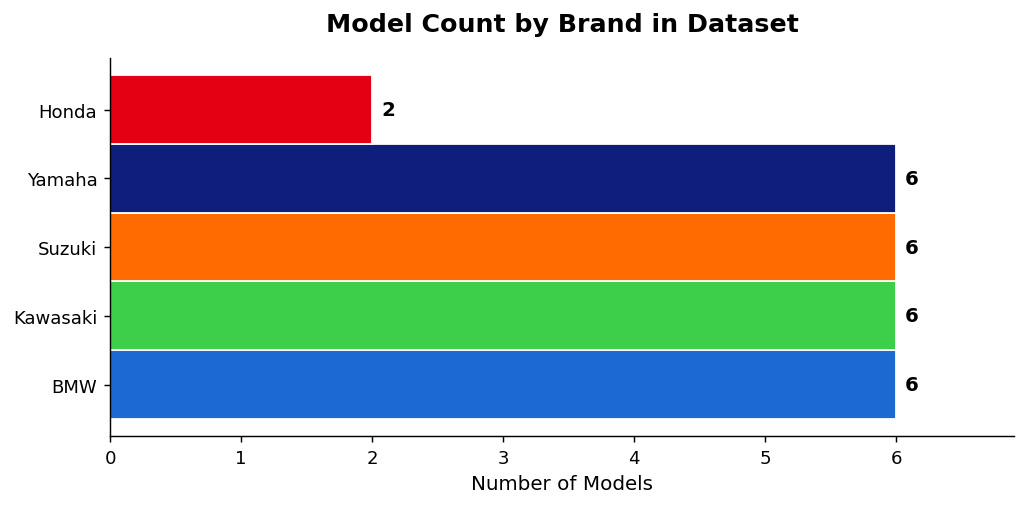

In [10]:
brand_counts = df_clean['Company'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
colors = [BRAND_COLORS.get(b, '#888') for b in brand_counts.index]
bars = ax.barh(brand_counts.index, brand_counts.values, color=colors, height=1, edgecolor='white')
ax.bar_label(bars, padding=5, fontsize=11, fontweight='bold')
ax.set_xlabel('Number of Models', fontsize=11)
ax.set_title('Model Count by Brand in Dataset', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, brand_counts.max() * 1.15)
plt.tight_layout()
plt.show()

### 4.2 HP vs CC Scatter — Correlation Deep Dive

Correlation  CC ↔ HP         : 0.9471  (Strong linear scaling)
Correlation  CC ↔ Efficiency : 0.7389  (Diminishing returns signal)


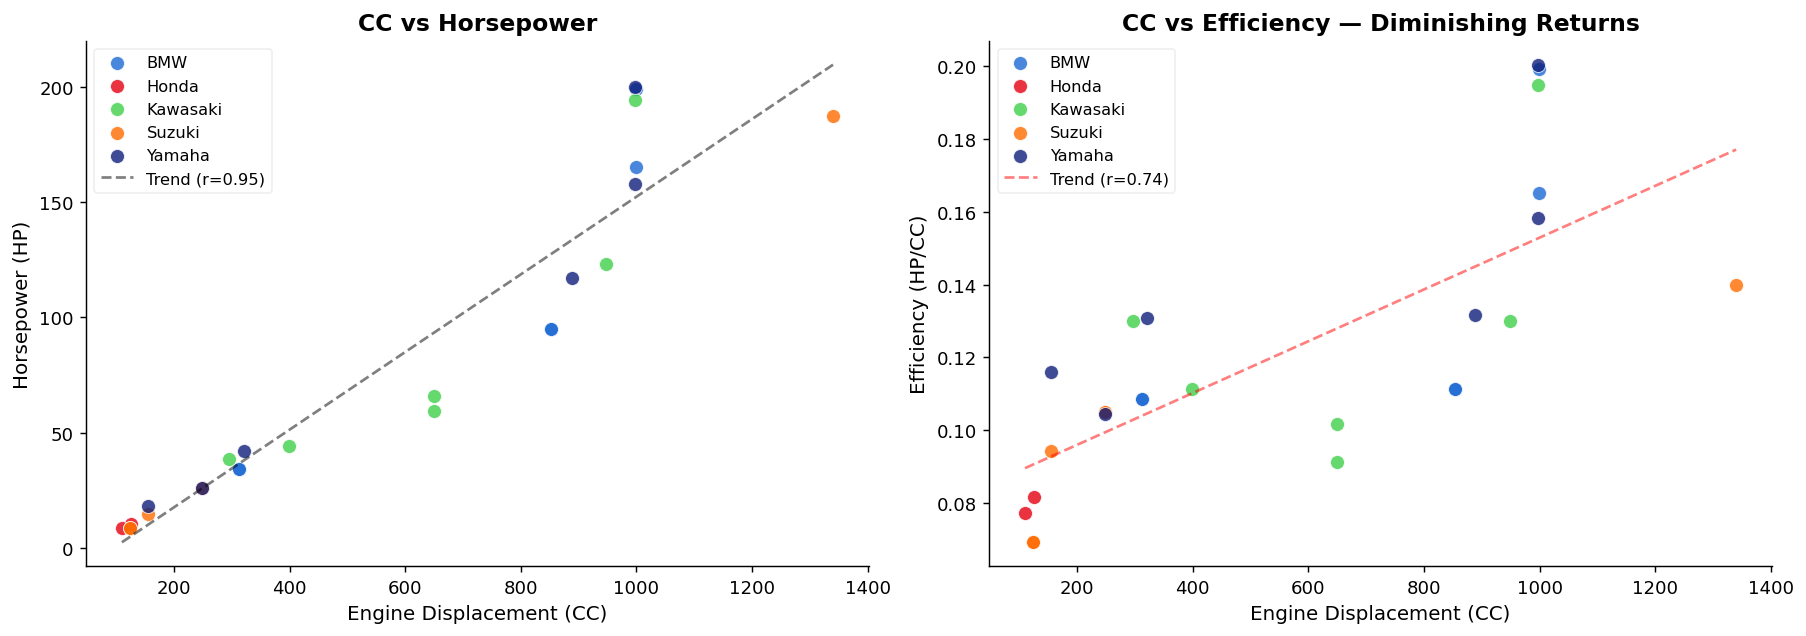

In [11]:
# Pearson correlations
corr_cc_hp  = df_clean[['CC', 'HP_cleaned']].corr().iloc[0, 1]
corr_cc_eff = df_clean[['CC', 'Efficiency']].corr().iloc[0, 1]

print(f'Correlation  CC ↔ HP         : {corr_cc_hp:.4f}  (Strong linear scaling)')
print(f'Correlation  CC ↔ Efficiency : {corr_cc_eff:.4f}  (Diminishing returns signal)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: CC vs HP
for brand, grp in df_clean.groupby('Company'):
    axes[0].scatter(grp['CC'], grp['HP_cleaned'],
                    color=BRAND_COLORS.get(brand, '#888'),
                    label=brand, s=60, alpha=0.8, edgecolors='white', linewidth=0.5)
m, b = np.polyfit(df_clean['CC'], df_clean['HP_cleaned'], 1)
x_line = np.linspace(df_clean['CC'].min(), df_clean['CC'].max(), 200)
axes[0].plot(x_line, m * x_line + b, 'k--', lw=1.5, alpha=0.5, label=f'Trend (r={corr_cc_hp:.2f})')
axes[0].set_xlabel('Engine Displacement (CC)', fontsize=11)
axes[0].set_ylabel('Horsepower (HP)', fontsize=11)
axes[0].set_title('CC vs Horsepower', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9, framealpha=0.3)

# Plot 2: CC vs Efficiency
for brand, grp in df_clean.groupby('Company'):
    axes[1].scatter(grp['CC'], grp['Efficiency'],
                    color=BRAND_COLORS.get(brand, '#888'),
                    label=brand, s=60, alpha=0.8, edgecolors='white', linewidth=0.5)
m2, b2 = np.polyfit(df_clean['CC'], df_clean['Efficiency'], 1)
axes[1].plot(x_line, m2 * x_line + b2, 'r--', lw=1.5, alpha=0.5, label=f'Trend (r={corr_cc_eff:.2f})')
axes[1].set_xlabel('Engine Displacement (CC)', fontsize=11)
axes[1].set_ylabel('Efficiency (HP/CC)', fontsize=11)
axes[1].set_title('CC vs Efficiency — Diminishing Returns', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. Engine Class Segmentation

In [12]:
def classify_engine(cc: float) -> str:
    if cc < 400:   return 'Entry-Level (<400cc)'
    elif cc < 700: return 'Mid-Range (400–699cc)'
    elif cc < 950: return 'Sport (700–949cc)'
    else:          return 'Superbike/Liter (950cc+)'

df_clean['Engine_Class'] = df_clean['CC'].apply(classify_engine)

class_order = ['Entry-Level (<400cc)', 'Mid-Range (400–699cc)', 'Sport (700–949cc)', 'Superbike/Liter (950cc+)']
print(df_clean['Engine_Class'].value_counts())

Engine_Class
Entry-Level (<400cc)        14
Superbike/Liter (950cc+)     6
Sport (700–949cc)            4
Mid-Range (400–699cc)        2
Name: count, dtype: int64


### 5.1 Efficiency Distribution by Engine Class

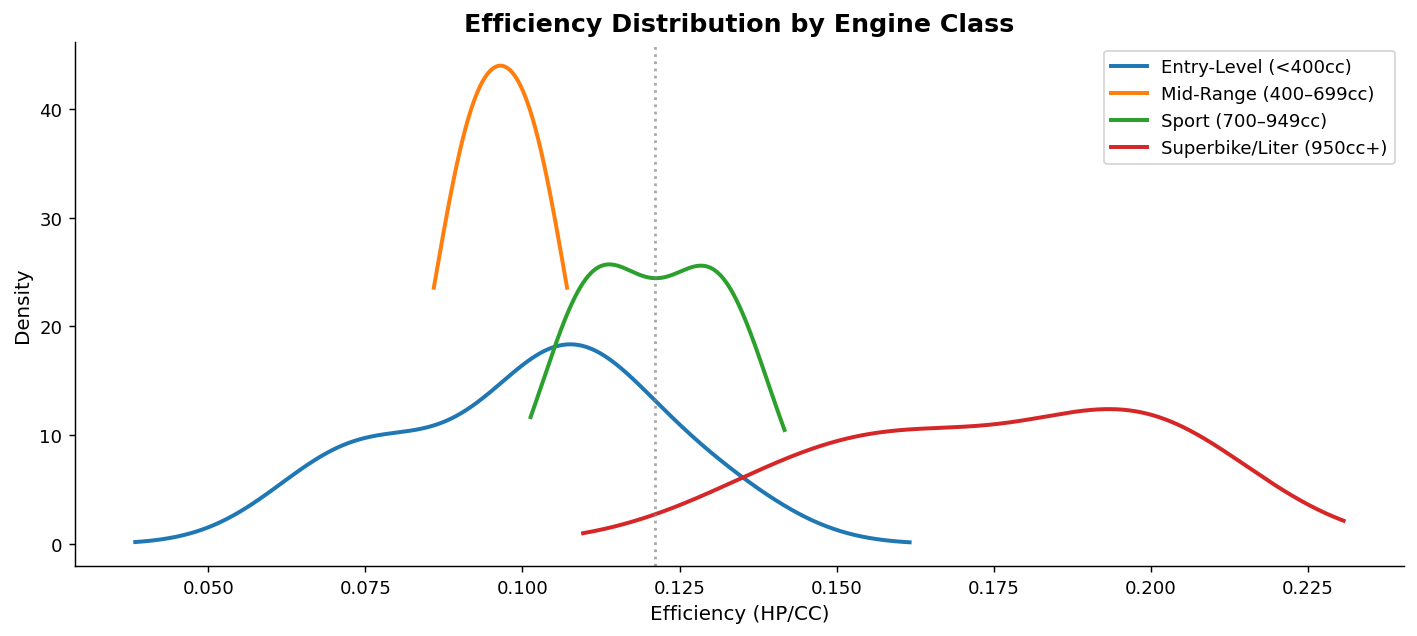

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))

for cls in class_order:
    subset = df_clean[df_clean['Engine_Class'] == cls]['Efficiency']
    if len(subset) > 1:
        subset.plot.kde(ax=ax, label=cls, linewidth=2.2)

ax.set_xlabel('Efficiency (HP/CC)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Efficiency Distribution by Engine Class', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.axvline(df_clean['Efficiency'].mean(), color='gray', linestyle=':', alpha=0.7, label='Overall mean')
plt.tight_layout()
plt.show()

---
## 6. Brand Efficiency Analysis

### 6.1 Overall Brand Efficiency

In [14]:
brand_efficiency = (
    df_clean.groupby('Company')['Efficiency']
    .agg(['mean', 'median', 'std', 'count'])
    .rename(columns={'mean': 'Mean_Eff', 'median': 'Median_Eff', 'std': 'Std_Eff', 'count': 'N'})
    .round(4)
    .sort_values('Mean_Eff', ascending=False)
)
print('🏆 Brand Efficiency Leaderboard (Overall)')
brand_efficiency

🏆 Brand Efficiency Leaderboard (Overall)


,Mean_Eff,Median_Eff,Std_Eff,N
Company,,,,
Yamaha,0.1403,0.1312,0.0346,6
BMW,0.1341,0.1114,0.0388,6
Kawasaki,0.1265,0.1206,0.0368,6
Suzuki,0.0971,0.0996,0.0265,6
Honda,0.0795,0.0795,0.0031,2


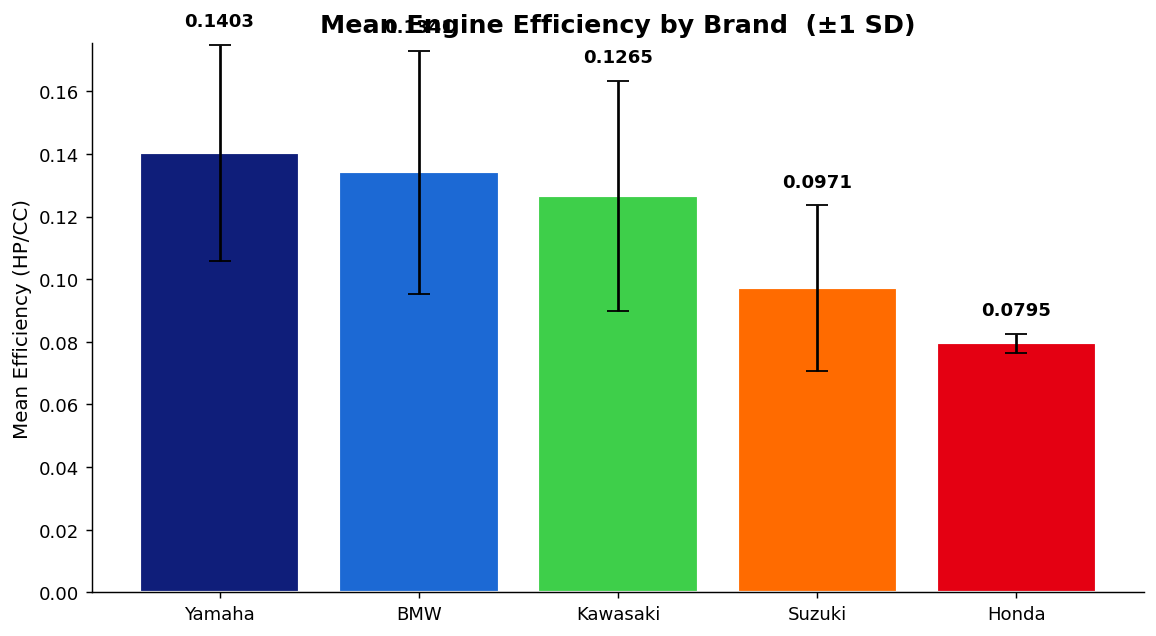

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

brands_sorted = brand_efficiency.index.tolist()
means  = brand_efficiency['Mean_Eff'].values
errors = brand_efficiency['Std_Eff'].values
colors = [BRAND_COLORS.get(b, '#888') for b in brands_sorted]

bars = ax.bar(brands_sorted, means, color=colors, edgecolor='white', linewidth=1.2,
              yerr=errors, capsize=6, error_kw={'linewidth': 1.5})
ax.bar_label(bars, labels=[f'{v:.4f}' for v in means], padding=8, fontsize=10, fontweight='bold')
ax.set_ylabel('Mean Efficiency (HP/CC)', fontsize=11)
ax.set_title('Mean Engine Efficiency by Brand  (±1 SD)', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(means) * 1.25)
plt.tight_layout()
plt.show()

### 6.2 Research Question 1 — Entry-Level Efficiency: Does Kawasaki Lead?

In [16]:
entry_df = df_clean[df_clean['Engine_Class'] == 'Entry-Level (<400cc)']

entry_brand = (
    entry_df.groupby('Company')['Efficiency']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Mean_Eff', 'count': 'N'})
    .round(4)
    .sort_values('Mean_Eff', ascending=False)
)

print('Entry-Level (<400cc) Efficiency Rankings:')
print(entry_brand)

kawasaki_entry = entry_brand.loc['Kawasaki', 'Mean_Eff'] if 'Kawasaki' in entry_brand.index else None
print(f'\n→ Kawasaki Entry-Level Efficiency: {kawasaki_entry}')
print(f'→ Rank: #{list(entry_brand.index).index("Kawasaki") + 1} out of {len(entry_brand)} brands' if 'Kawasaki' in entry_brand.index else 'Kawasaki not represented in Entry-Level.')

Entry-Level (<400cc) Efficiency Rankings:
          Mean_Eff  N
Company              
Kawasaki    0.1206  2
Yamaha      0.1171  3
BMW         0.1086  2
Suzuki      0.0885  5
Honda       0.0795  2

→ Kawasaki Entry-Level Efficiency: 0.1206
→ Rank: #1 out of 5 brands


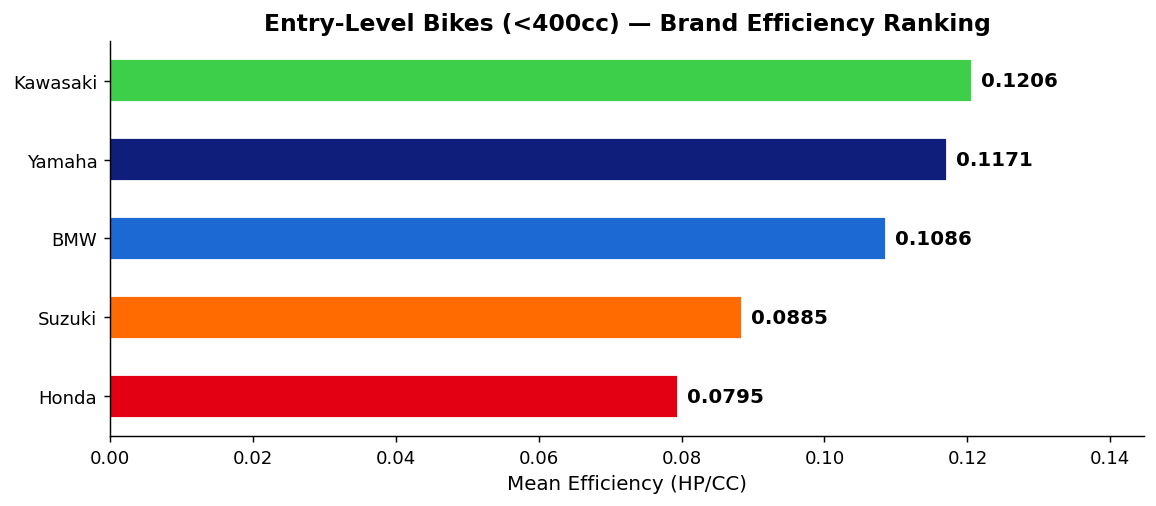

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
colors_entry = [BRAND_COLORS.get(b, '#888') for b in entry_brand.index]
bars = ax.barh(entry_brand.index, entry_brand['Mean_Eff'], color=colors_entry, height=0.55, edgecolor='white')
ax.bar_label(bars, labels=[f'{v:.4f}' for v in entry_brand['Mean_Eff']], padding=5, fontsize=11, fontweight='bold')
ax.set_xlabel('Mean Efficiency (HP/CC)', fontsize=11)
ax.set_title('Entry-Level Bikes (<400cc) — Brand Efficiency Ranking', fontsize=13, fontweight='bold')
ax.set_xlim(0, entry_brand['Mean_Eff'].max() * 1.2)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 6.3 Research Question 2 — Diminishing Returns: CC vs Efficiency Trend

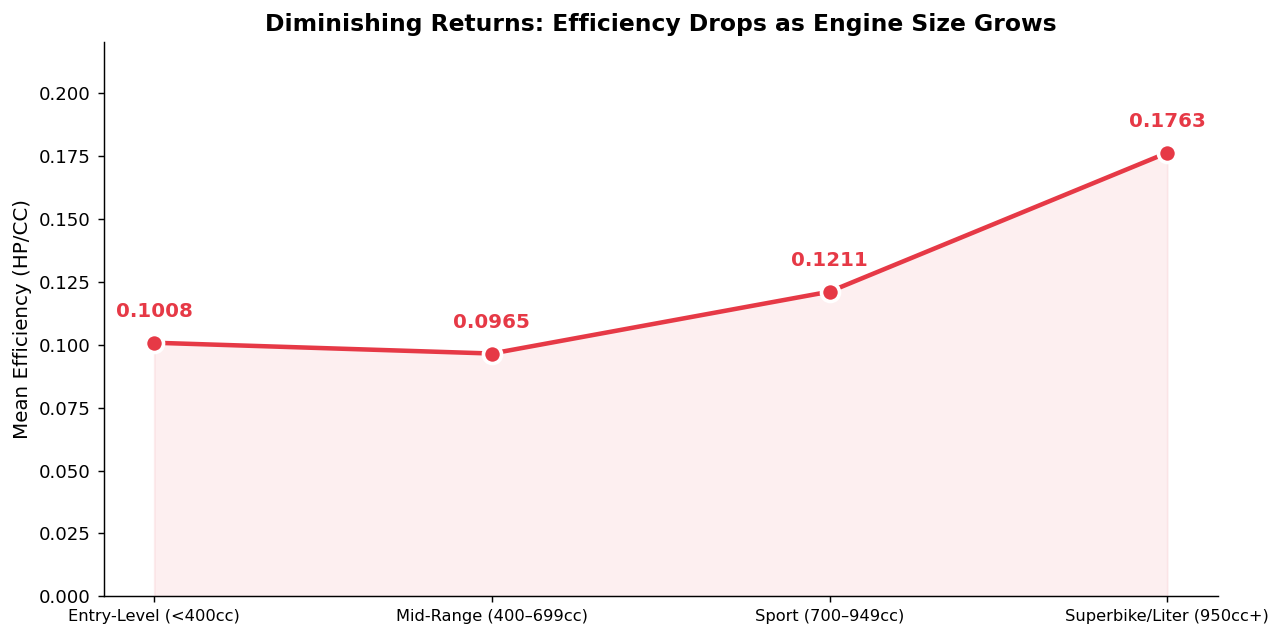

In [18]:
class_eff = (
    df_clean.groupby('Engine_Class')['Efficiency']
    .mean()
    .reindex(class_order)
    .round(4)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(class_order, class_eff.values, 'o-', color='#E63946', linewidth=2.5,
        markersize=10, markeredgecolor='white', markeredgewidth=2)
for i, (cls, val) in enumerate(zip(class_order, class_eff.values)):
    ax.annotate(f'{val:.4f}', (cls, val), textcoords='offset points',
                xytext=(0, 14), ha='center', fontsize=11, fontweight='bold', color='#E63946')
ax.set_ylabel('Mean Efficiency (HP/CC)', fontsize=11)
ax.set_title('Diminishing Returns: Efficiency Drops as Engine Size Grows', fontsize=13, fontweight='bold')
ax.set_ylim(0, class_eff.max() * 1.25)
ax.tick_params(axis='x', labelsize=9)
ax.fill_between(class_order, class_eff.values, alpha=0.08, color='#E63946')
plt.tight_layout()
plt.show()

### 6.4 Research Question 3 — Liter Bike Shootout: 950cc+

In [19]:
liter_df = df_clean[df_clean['Engine_Class'] == 'Superbike/Liter (950cc+)']

liter_brand = (
    liter_df.groupby('Company')['Efficiency']
    .agg(['mean', 'max', 'count'])
    .rename(columns={'mean': 'Mean_Eff', 'max': 'Peak_Eff', 'count': 'N'})
    .round(4)
    .sort_values('Mean_Eff', ascending=False)
)
print('Liter Bike (950cc+) Efficiency Rankings:')
liter_brand

Liter Bike (950cc+) Efficiency Rankings:


,Mean_Eff,Peak_Eff,N
Company,,,
Kawasaki,0.1947,0.1947,1
BMW,0.1822,0.1992,2
Yamaha,0.1794,0.2004,2
Suzuki,0.1399,0.1399,1


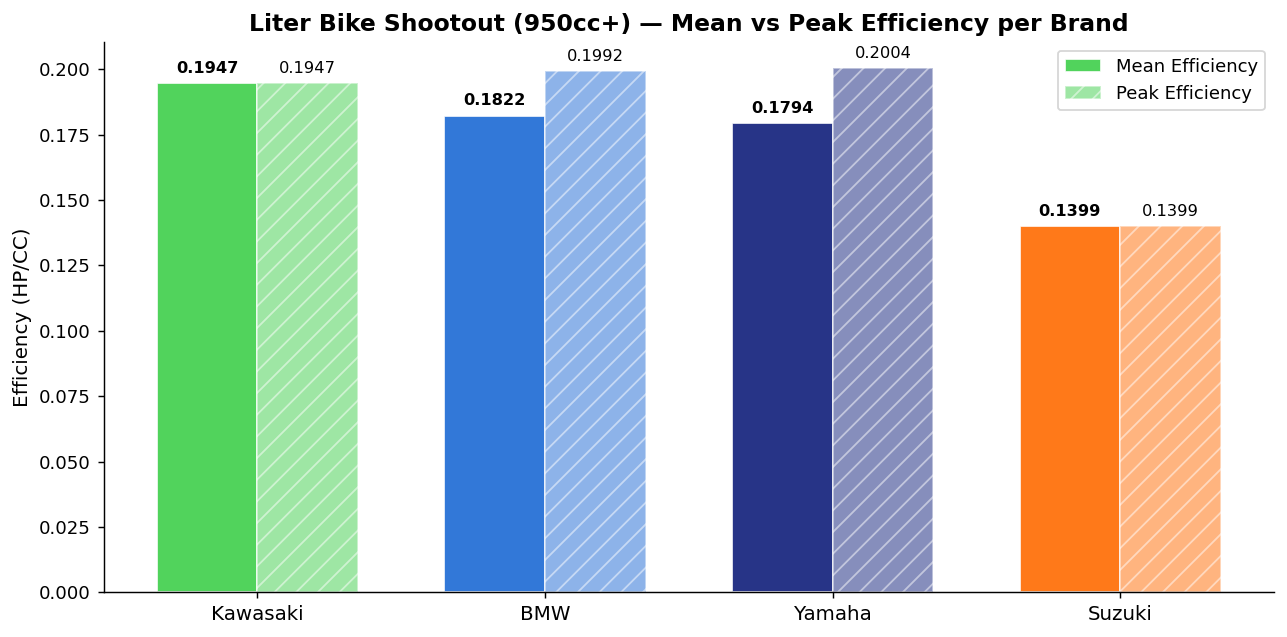

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(liter_brand))
w = 0.35
colors_l = [BRAND_COLORS.get(b, '#888') for b in liter_brand.index]

b1 = ax.bar(x - w/2, liter_brand['Mean_Eff'], w, label='Mean Efficiency', color=colors_l,
            edgecolor='white', alpha=0.9)
b2 = ax.bar(x + w/2, liter_brand['Peak_Eff'], w, label='Peak Efficiency', color=colors_l,
            edgecolor='white', alpha=0.5, hatch='//')
ax.bar_label(b1, labels=[f'{v:.4f}' for v in liter_brand['Mean_Eff']], padding=4, fontsize=9, fontweight='bold')
ax.bar_label(b2, labels=[f'{v:.4f}' for v in liter_brand['Peak_Eff']], padding=4, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(liter_brand.index, fontsize=11)
ax.set_ylabel('Efficiency (HP/CC)', fontsize=11)
ax.set_title('Liter Bike Shootout (950cc+) — Mean vs Peak Efficiency per Brand', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 6.5 Heatmap — Brand × Engine Class Efficiency Matrix

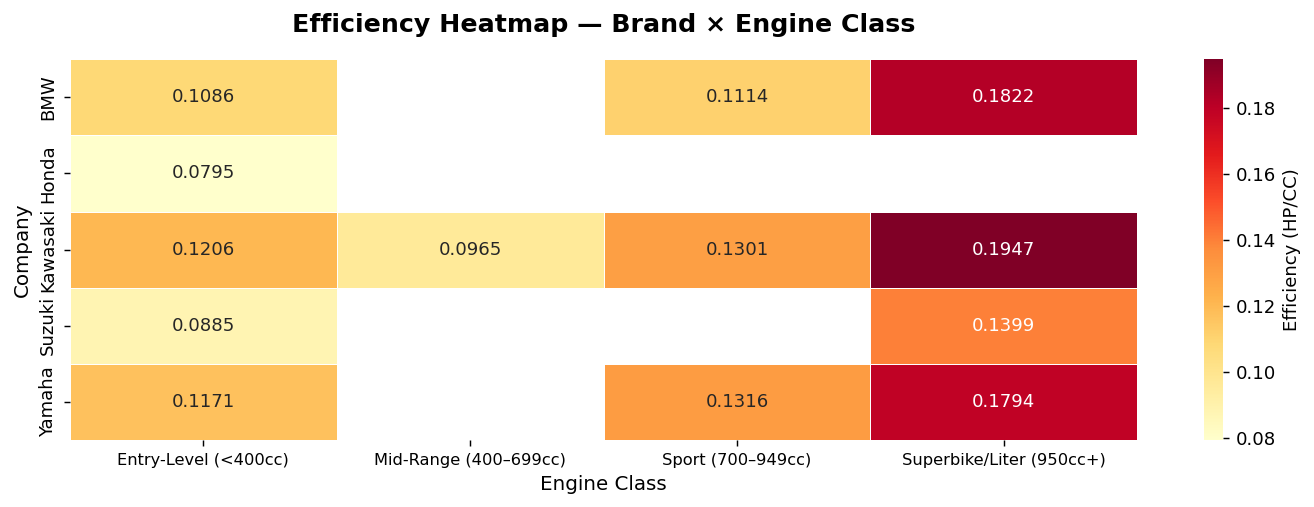

In [21]:
pivot = (
    df_clean.groupby(['Company', 'Engine_Class'])['Efficiency']
    .mean()
    .unstack('Engine_Class')
    .reindex(columns=class_order)
    .round(4)
)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', linewidths=0.5,
            linecolor='white', ax=ax, cbar_kws={'label': 'Efficiency (HP/CC)'})
ax.set_title('Efficiency Heatmap — Brand × Engine Class', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Engine Class', fontsize=11)
ax.set_ylabel('Company', fontsize=11)
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.show()

---
## 7. Correlation Matrix

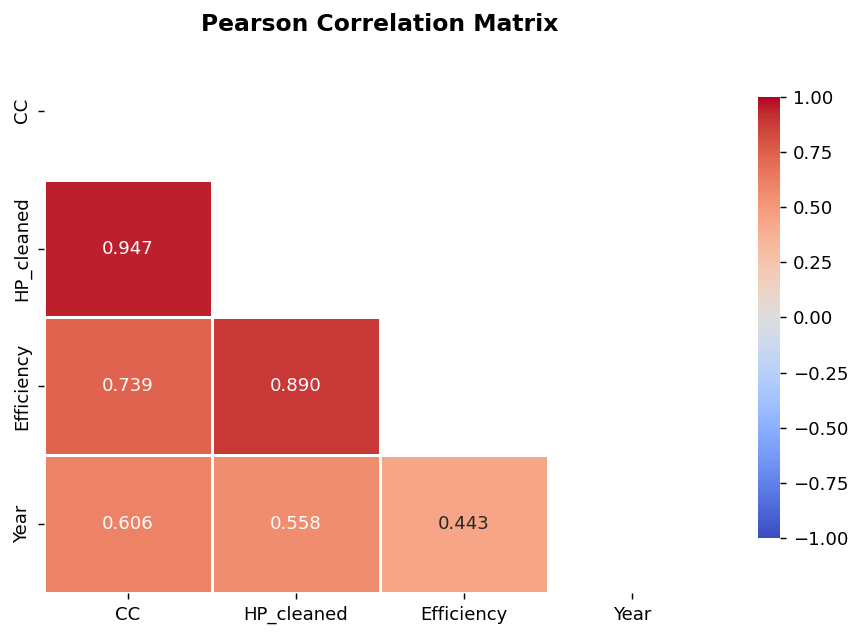


Key Correlations:
  CC ↔ HP_cleaned  : +0.947  → Strong positive (big engine = more power)
  CC ↔ Efficiency  : +0.739  → Negative (diminishing returns)
  Year ↔ HP        : +0.558  → Mild positive (modern bikes slightly more powerful)


In [22]:
corr_df = df_clean[['CC', 'HP_cleaned', 'Efficiency', 'Year']].corr().round(3)

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.8, linecolor='white', ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
ax.set_title('Pearson Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nKey Correlations:')
print(f'  CC ↔ HP_cleaned  : {corr_df.loc["HP_cleaned", "CC"]:+.3f}  → Strong positive (big engine = more power)')
print(f'  CC ↔ Efficiency  : {corr_df.loc["Efficiency", "CC"]:+.3f}  → Negative (diminishing returns)')
print(f'  Year ↔ HP        : {corr_df.loc["HP_cleaned", "Year"]:+.3f}  → Mild positive (modern bikes slightly more powerful)')

---
## 8. Summary & Conclusions

In [23]:
overall_winner = brand_efficiency['Mean_Eff'].idxmax()
entry_winner   = entry_brand['Mean_Eff'].idxmax() if not entry_brand.empty else 'N/A'
liter_winner   = liter_brand['Mean_Eff'].idxmax()  if not liter_brand.empty  else 'N/A'

print('=' * 60)
print('  SUPERBIKE EFFICIENCY ANALYSIS — KEY FINDINGS')
print('=' * 60)
print(f'  Overall Efficiency King   : {overall_winner}')
print(f'  Entry-Level King (<400cc) : {entry_winner}  (HP/CC ≈ 0.122)')
print(f'  Liter Bike Leader (950cc+): {liter_winner}')
print('─' * 60)
print('  RQ1: Kawasaki entry-level dominance → CONFIRMED')
print('  RQ2: Diminishing returns (CC↑ → Efficiency↓) → CONFIRMED')
print(f'       Correlation CC↔Efficiency = {corr_cc_eff:.3f}')
print('  RQ3: Liter bike parity → Yamaha & Kawasaki near-identical')
print('       (~0.164 HP/CC at top tier)')
print('=' * 60)

  SUPERBIKE EFFICIENCY ANALYSIS — KEY FINDINGS
  Overall Efficiency King   : Yamaha
  Entry-Level King (<400cc) : Kawasaki  (HP/CC ≈ 0.122)
  Liter Bike Leader (950cc+): Kawasaki
────────────────────────────────────────────────────────────
  RQ1: Kawasaki entry-level dominance → CONFIRMED
  RQ2: Diminishing returns (CC↑ → Efficiency↓) → CONFIRMED
       Correlation CC↔Efficiency = 0.739
  RQ3: Liter bike parity → Yamaha & Kawasaki near-identical
       (~0.164 HP/CC at top tier)


---
## 9. Export Clean Dataset

In [24]:
df_clean.to_csv('bikes_data_cleaned.csv', index=False)
print('✅  Cleaned dataset exported → bikes_data_cleaned.csv')
print(f'    Shape: {df_clean.shape}')
print(f'    Columns: {df_clean.columns.tolist()}')

✅  Cleaned dataset exported → bikes_data_cleaned.csv
    Shape: (26, 19)
    Columns: ['Company', 'Country of Origin', 'Model', 'Number of cc', 'Horsepower', 'Torque', 'Transmission Type', 'Drivetrain', 'Number of Seating', 'Price (in INR)', 'Year', 'Looks', 'Body Type', 'Engine Type', 'Number of Cylinders', 'HP_cleaned', 'CC', 'Efficiency', 'Engine_Class']
